Bài mới

In [ ]:
# ============================================================
# CELL 1: INSTALL -- Cai causal-conv1d & mamba-ssm + DEAP
#   Chay cell nay TRUOC, sau do RESTART KERNEL, roi moi chay Cell 2.
# ============================================================
import importlib
import json
import platform
import re
import site
import subprocess
import sys
import urllib.request
from pathlib import Path
from importlib.util import find_spec


def run_cmd(cmd):
    print('Running:', ' '.join(cmd))
    subprocess.check_call(cmd)

def run_capture(cmd):
    print('Running:', ' '.join(cmd))
    p = subprocess.run(cmd, text=True, capture_output=True)
    if p.returncode != 0:
        print(p.stdout); print(p.stderr)
    return p

def pip_install(args):
    run_cmd([sys.executable, '-m', 'pip', 'install', '--no-cache-dir', '--prefer-binary'] + args)

def pip_install_force(args):
    run_cmd([sys.executable, '-m', 'pip', 'install', '--force-reinstall', '--no-cache-dir'] + args)

def pip_uninstall(packages):
    run_cmd([sys.executable, '-m', 'pip', 'uninstall', '-y'] + packages)


def fetch_release_assets(repo: str):
    assets = []
    page = 1
    while True:
        url = f'https://api.github.com/repos/{repo}/releases?per_page=100&page={page}'
        data = json.load(urllib.request.urlopen(url))
        if not data:
            break
        for rel in data:
            tag = rel.get('tag_name', '')
            for a in rel.get('assets', []):
                assets.append({'name': a.get('name', ''), 'url': a.get('browser_download_url', ''), 'tag': tag})
        if len(data) < 100:
            break
        page += 1
    return assets


def wheel_version(name: str, prefix: str):
    from packaging.version import Version
    core = name[len(prefix):].split('+', 1)[0]
    try:
        return Version(core)
    except Exception:
        return Version('0')


def parse_build_tags(name: str):
    m = re.search(r'\+(cu\d+|cu\d{3})(torch[0-9.]+)(cxx11abi(?:TRUE|FALSE))-', name)
    if not m:
        return None, None, None
    return m.group(1), m.group(2), m.group(3)


def wheel_candidates(assets, prefix: str, py_tag: str, platform_tag: str):
    suffix = f'-{py_tag}-{py_tag}-{platform_tag}.whl'
    out = []
    for a in assets:
        n = a['name']
        if not n.startswith(prefix) or not n.endswith(suffix):
            continue
        cu_tag, torch_tag, abi_tag = parse_build_tags(n)
        if not cu_tag:
            continue
        out.append({'name': n, 'url': a['url'], 'tag': a['tag'],
                    'version': wheel_version(n, prefix),
                    'cu_tag': cu_tag, 'torch_tag': torch_tag, 'abi_tag': abi_tag})
    out.sort(key=lambda x: x['version'], reverse=True)
    return out


def pref_index(x: str, choices):
    try:
        return choices.index(x)
    except ValueError:
        return len(choices) + 99


def key_rank(key, torch_choices, cu_choices, abi_choices):
    cu_tag, torch_tag, abi_tag = key
    return (pref_index(torch_tag, torch_choices),
            pref_index(cu_tag, cu_choices),
            pref_index(abi_tag, abi_choices))


def patch_mamba_init_for_kaggle():
    py_ver = f'python{sys.version_info.major}.{sys.version_info.minor}'
    candidates = [Path(p) / 'mamba_ssm' / '__init__.py' for p in site.getsitepackages()]
    user_site = site.getusersitepackages()
    if user_site:
        candidates.append(Path(user_site) / 'mamba_ssm' / '__init__.py')
    candidates += [
        Path(sys.prefix) / 'lib' / py_ver / 'site-packages' / 'mamba_ssm' / '__init__.py',
        Path('/usr/local/lib') / py_ver / 'dist-packages' / 'mamba_ssm' / '__init__.py',
    ]
    target = next((c for c in candidates if c.exists()), None)
    if target is None:
        print('WARN: mamba_ssm __init__.py not found for patch'); return
    txt = target.read_text(encoding='utf-8')
    old = 'from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel'
    new = 'try:\n    from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel\nexcept Exception:\n    MambaLMHeadModel = None'
    if old in txt:
        target.write_text(txt.replace(old, new), encoding='utf-8')
        print('Patched:', target)
    else:
        print('No patch needed in:', target)


def validate_binary_imports():
    code = (
        'import torch\n'
        'import selective_scan_cuda\n'
        'from mamba_ssm import Mamba, Mamba2\n'
        "print('BINARY_IMPORT_OK', torch.__version__)\n"
    )
    p = run_capture([sys.executable, '-c', code])
    return p.returncode == 0


# ---------------------------------------------------------------
# [FIX] Lay thong tin torch qua SUBPROCESS truoc pip installs.
# KHONG import torch truc tiep trong cell nay:
#   pip install gluonts/gpytorch corrupt sys.modules['torch.optim']
#   -> 'import torch' that bai voi 'del adadelta' trong session hien tai.
# Sau khi RESTART KERNEL, torch se duoc import sach se trong Cell 2.
# ---------------------------------------------------------------
print('Python:', sys.version)
_ti_raw = subprocess.check_output(
    [sys.executable, '-c',
     'import torch, json; print(json.dumps({'
     '"ver": torch.__version__, '
     '"cuda": torch.version.cuda or "", '
     '"abi": bool(getattr(torch._C, "_GLIBCXX_USE_CXX11_ABI", False))'
     '}))'],
    text=True,
).strip()
_ti = json.loads(_ti_raw)
print(f'[PRE-INSTALL] torch={_ti["ver"]} | cuda={_ti["cuda"]} | abi={_ti["abi"]}')

pip_install(['-q', 'appdirs==1.4.4', 'pyyaml', 'submitit', 'packaging'])
pip_install(['-q', 'gluonts==0.15.1', 'torchmetrics==1.4.2', 'gpytorch==1.13', 'utilsforecast==0.2.5'])
pip_install(['-q', 'wandb', 'matplotlib', 'seaborn'])
pip_install(['-q', 'pulp', 'deap'])  # MILP + GA framework

# ---- Detect env tags (dung subprocess info, KHONG import torch) ----
py_tag       = f'cp{sys.version_info.major}{sys.version_info.minor}'
platform_tag = 'linux_x86_64' if platform.machine().lower() in {'x86_64', 'amd64'} else 'linux_aarch64'
torch_mm     = '.'.join(_ti['ver'].split('+')[0].split('.')[:2])
torch_tag_current = f'torch{torch_mm}'
cu_major     = _ti['cuda'].split('.')[0] if _ti['cuda'] else '12'
cu_tag_current  = f'cu{cu_major}'
abi_tag_current = 'cxx11abiTRUE' if _ti['abi'] else 'cxx11abiFALSE'

torch_choices = [torch_tag_current, 'torch2.10', 'torch2.9', 'torch2.8', 'torch2.7', 'torch2.6', 'torch2.5', 'torch2.4', 'torch2.3', 'torch2.2']
cu_choices    = [cu_tag_current, 'cu13', 'cu12', 'cu124', 'cu122', 'cu11', 'cu118']
abi_choices   = [abi_tag_current, 'cxx11abiTRUE', 'cxx11abiFALSE']

print('Env tags:  py=%s | platform=%s | torch=%s | cu=%s | abi=%s' %
      (py_tag, platform_tag, torch_tag_current, cu_tag_current, abi_tag_current))

# ---- Fetch release wheels ----
causal_assets = fetch_release_assets('Dao-AILab/causal-conv1d')
mamba_assets  = fetch_release_assets('state-spaces/mamba')

causal_cands = wheel_candidates(causal_assets, 'causal_conv1d-', py_tag, platform_tag)
mamba_cands  = wheel_candidates(mamba_assets,  'mamba_ssm-',    py_tag, platform_tag)

print(f'Wheel candidates matched: causal_conv1d={len(causal_cands)} | mamba_ssm={len(mamba_cands)}')
if not causal_cands or not mamba_cands:
    raise RuntimeError('No wheel candidates matched. Check py/platform tags above.')

causal_map = {(c['cu_tag'], c['torch_tag'], c['abi_tag']): c for c in reversed(causal_cands)}
mamba_map  = {(m['cu_tag'], m['torch_tag'], m['abi_tag']): m for m in reversed(mamba_cands)}

common_keys = sorted(
    set(causal_map.keys()) & set(mamba_map.keys()),
    key=lambda k: key_rank(k, torch_choices, cu_choices, abi_choices),
)
print(f'Common build keys: {len(common_keys)}')
for k in common_keys[:5]:
    print(' ', k)

if not common_keys:
    raise RuntimeError('No common (cu, torch, abi) key found. Cannot install matching wheels.')

# ---- Try installing each matching pair until binary validation passes ----
success = False
for idx, k in enumerate(common_keys[:12], start=1):
    c, m = causal_map[k], mamba_map[k]
    print(f'\nAttempt {idx}: key={k}')
    print('  causal:', c['name'], '/', c['tag'])
    print('  mamba :', m['name'], '/', m['tag'])
    pip_uninstall(['mamba-ssm', 'causal-conv1d', 'mamba_ssm', 'causal_conv1d'])
    pip_install_force([c['url']])
    pip_install_force([m['url']])
    patch_mamba_init_for_kaggle()
    sys.modules.pop('mamba_ssm', None)
    importlib.invalidate_caches()
    if validate_binary_imports():
        print('Binary validation passed.')
        success = True
        break

if not success:
    raise RuntimeError('All attempts failed. Copy this cell output to debug.')

print('\n  causal_conv1d ->', find_spec('causal_conv1d') is not None)
print('  mamba_ssm     ->', find_spec('mamba_ssm') is not None)
print('  pulp          ->', find_spec('pulp') is not None)
print('  deap          ->', find_spec('deap') is not None)
print('\n=== INSTALL DONE --- RESTART KERNEL, THEN RUN CELL 2 -> CELL 9 ===')
raise SystemExit('Restart kernel now.')

In [1]:
# ============================================================
# CELL 2: SETUP — Load files, Load model (SAU khi restart kernel)
# ============================================================
from pathlib import Path
import sys, numpy as np, pandas as pd, torch

INPUT_ROOT = Path('/kaggle/input')
WORK_ROOT = Path('/kaggle/working')

def find_first(filename: str) -> Path:
    matches = sorted(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f'Không tìm thấy: {filename}')
    if len(matches) > 1:
        print(f'  WARN: {len(matches)} files for {filename}, dùng {matches[0]}')
    return matches[0]


def require_volume_panel(filename: str, role: str) -> Path:
    matches = sorted(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f'Thiếu file volume bắt buộc cho {role}: {filename}. '
            'Notebook chỉ cho phép panel volume. '
            'Hãy attach dataset chứa đủ 3 file: '
            'olist_panel_volume_opt_train.csv, olist_panel_volume_opt_val.csv, olist_panel_volume_opt_test.csv.'
        )
    if len(matches) > 1:
        print(f'  WARN: {len(matches)} files for {filename}, dùng {matches[0]}')
    return matches[0]


repo_root = None
for src_torch in INPUT_ROOT.rglob('src_torch'):
    repo_root = src_torch.parent
    break
if repo_root is None:
    raise FileNotFoundError('Không tìm thấy src_torch/')

# Chỉ nhận panel volume: không fallback sang panel thường để tránh lệch đơn vị.
train_csv = require_volume_panel('olist_panel_volume_opt_train.csv', 'train_csv')
val_csv = require_volume_panel('olist_panel_volume_opt_val.csv', 'val_csv')
test_csv = require_volume_panel('olist_panel_volume_opt_test.csv', 'test_csv')
regions_csv = find_first('step1_micro_regions_nodes.csv')
ckpt_path = find_first('mamba4cast_2l_1024_conv_i5e5.pth')

print('=== Đường dẫn files ===')
for label, p in [('repo_root', repo_root), ('ckpt_path', ckpt_path),
                  ('train_csv', train_csv), ('val_csv', val_csv),
                  ('test_csv', test_csv), ('regions_csv', regions_csv)]:
    print(f'  {label:<12}: {p}')

sys.path.insert(0, str(repo_root / 'src_torch'))
from training.models import SSMModelMulti

SSM_CONFIG = {
    'residual': False, 'num_encoder_layers': 2, 'token_embed_len': 1024,
    'initial_gelu_flag': True, 'in_proj_norm': False, 'norm': True,
    'norm_type': 'layernorm', 'global_residual': False, 'linear_seq': 15,
    'mamba2': True, 'bidirectional': False, 'enc_conv': True,
    'init_dil_conv': True, 'enc_conv_kernel': 5, 'init_conv_kernel': 5,
    'init_conv_max_dilation': 3, 'd_state': 128, 'block_expansion': 2,
}
SCALER = 'min_max'
SUB_DAY = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDEVICE: {DEVICE}')
if str(DEVICE) == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

def adapt_state_dict_keys(sd):
    return {k.replace('linear_layer', 'stage_2_layer.0'): v for k, v in sd.items()}

model = SSMModelMulti(scaler=SCALER, sin_pos_enc=False, sin_pos_const=100.0,
                      sub_day=SUB_DAY, encoding_dropout=0.0, handle_constants_model=False,
                      **SSM_CONFIG).to(DEVICE)

raw_ckpt = torch.load(str(ckpt_path), map_location='cpu')
state = raw_ckpt.get('model_state_dict', raw_ckpt) if isinstance(raw_ckpt, dict) else raw_ckpt
state = adapt_state_dict_keys(state)
missing, unexpected = model.load_state_dict(state, strict=False)
model.eval()
print('Checkpoint loaded OK')
print(f'  missing_keys: {len(missing)} | unexpected_keys: {len(unexpected)}')

=== Đường dẫn files ===
  repo_root   : /kaggle/input/datasets/thangpham1684/mamba4cast-code/Mamba4Cast-main
  ckpt_path   : /kaggle/input/datasets/thangpham1684/mamba4cast-2l-1024-conv-i5e5-pth/mamba4cast_2l_1024_conv_i5e5.pth
  train_csv   : /kaggle/input/datasets/thangpham1684/olist-dataset/olist_panel_volume_opt_train.csv
  val_csv     : /kaggle/input/datasets/thangpham1684/olist-dataset/olist_panel_volume_opt_val.csv
  test_csv    : /kaggle/input/datasets/thangpham1684/olist-dataset/olist_panel_volume_opt_test.csv
  regions_csv : /kaggle/input/datasets/thangpham1684/olist-dataset/step1_micro_regions_nodes.csv

DEVICE: cuda
GPU: Tesla T4
Checkpoint loaded OK
  missing_keys: 0 | unexpected_keys: 0


In [2]:
# ============================================================
# CELL 3: INFERENCE — Mamba4Cast dự báo nhu cầu từng tuyến OD
# (Bao gồm Đánh giá & Dự báo tương lai)
# ============================================================
import time
import numpy as np
import pandas as pd
import torch

def make_time_features(ds: pd.Series, sub_day: bool = True) -> np.ndarray:
    dt = pd.to_datetime(ds)
    if sub_day:
        feats = np.stack([dt.dt.year.values, dt.dt.month.values, dt.dt.day.values,
                          dt.dt.dayofweek.values + 1, dt.dt.dayofyear.values,
                          dt.dt.hour.values, dt.dt.minute.values], axis=-1)
    else:
        feats = np.stack([dt.dt.year.values, dt.dt.month.values, dt.dt.day.values,
                          dt.dt.dayofweek.values + 1, dt.dt.dayofyear.values], axis=-1)
    return feats.astype(np.float32)

def inverse_scale(out_dict, scaler='min_max'):
    if scaler == 'min_max':
        return (out_dict['result'] * (out_dict['scale'][0].squeeze(-1) - out_dict['scale'][1].squeeze(-1))) + out_dict['scale'][1].squeeze(-1)
    if scaler == 'custom_robust':
        return (out_dict['result'] * out_dict['scale'][1].squeeze(-1)) + out_dict['scale'][0].squeeze(-1)
    return out_dict['result']

def load_panel(path) -> pd.DataFrame:
    df = pd.read_csv(path)
    out = df[['unique_id', 'ds', 'y']].copy()
    out['ds'] = pd.to_datetime(out['ds'])
    out['y'] = pd.to_numeric(out['y'])
    return out.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Lấy dữ liệu các tập để ghép làm lịch sử
hist_df = load_panel(train_csv)
val_df = load_panel(val_csv)
test_df = load_panel(test_csv)
print(f'Train {len(hist_df):,} rows | Val {len(val_df):,} rows | Test {len(test_df):,} rows')

# Tạo history cho tập Test = Train + Val (không có khoảng trống thời gian)
test_hist_df = pd.concat([hist_df, val_df]).sort_values(['unique_id', 'ds']).reset_index(drop=True)
test_hist_groups = {uid: g.sort_values('ds') for uid, g in test_hist_df.groupby('unique_id')}

# Tạo history cho Future Inference = Train + Val + Test (dự báo tương lai thực tế từ sau Test)
future_hist_df = pd.concat([hist_df, val_df, test_df]).sort_values(['unique_id', 'ds']).reset_index(drop=True)
future_hist_groups = {uid: g.sort_values('ds') for uid, g in future_hist_df.groupby('unique_id')}

# ============================================================
# 1. EVALUATION TRÊN TẬP TEST (Để lấy Metrics)
# ============================================================
def run_split_inference(hist_groups: dict, target_df: pd.DataFrame, split_name: str):
    tgt_groups = {uid: g.sort_values('ds') for uid, g in target_df.groupby('unique_id')}
    pred_rows = []
    start = time.time()
    with torch.no_grad():
        for i, uid in enumerate(sorted(tgt_groups.keys()), 1):
            if uid not in hist_groups:
                continue
            h, t = hist_groups[uid], tgt_groups[uid]
            if len(h) == 0 or len(t) == 0:
                continue
            pred_len = int(len(t))
            batch = {
                'ts': torch.from_numpy(make_time_features(h['ds'], SUB_DAY)).unsqueeze(0).to(DEVICE),
                'history': torch.from_numpy(h['y'].to_numpy(np.float32)).unsqueeze(0).to(DEVICE),
                'target_dates': torch.from_numpy(make_time_features(t['ds'], SUB_DAY)).unsqueeze(0).to(DEVICE),
                'task': torch.zeros((1, pred_len), dtype=torch.int64, device=DEVICE),
            }
            out = model(batch, prediction_length=pred_len, training=False, drop_enc_allow=False)
            yhat = inverse_scale(out, SCALER).squeeze(0).detach().cpu().numpy().astype(float)
            yhat = np.clip(yhat, 0, None)
            for ds_s, yt, yp in zip(t['ds'].dt.strftime('%Y-%m-%d'), t['y'].to_numpy(float), yhat):
                pred_rows.append({'unique_id': uid, 'ds': ds_s, 'y_true': float(yt), 'yhat_mamba': float(yp)})
            if i % 250 == 0:
                print(f'  [{split_name}] {i}/{len(tgt_groups)} series | {time.time()-start:.1f}s')
    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(WORK_ROOT / f'olist_mamba_{split_name}_predictions.csv', index=False)
    return pred_df

print('\n>>> Đang chạy Inference trên tập TEST để đánh giá mô hình...')
test_pred_df = run_split_inference(test_hist_groups, test_df, 'test')
print(f"Predictions: {len(test_pred_df):,} rows")

# ============================================================
# EVALUATION METRICS — theo Mamba4Cast paper (Appendix E.1)
# ============================================================
def compute_mase(y_true: np.ndarray, y_hat: np.ndarray, y_train: np.ndarray, seasonality: int = 1) -> float:
    n = len(y_train)
    if n <= seasonality:
        return float('nan')
    naive_errors = np.abs(y_train[seasonality:] - y_train[:-seasonality])
    scale = np.mean(naive_errors)
    if scale < 1e-10:
        return float('nan')
    return float(np.mean(np.abs(y_true - y_hat)) / scale)

def metric_dict(pred_df: pd.DataFrame, hist_groups: dict, seasonality: int = 1) -> dict:
    # Aggregating 4 weeks of the test set into 1 month for evaluation
    monthly_df = pred_df.groupby('unique_id').agg(
        y_true_monthly=('y_true', 'sum'),
        yhat_monthly=('yhat_mamba', 'sum')
    ).reset_index()
    
    yt = monthly_df['y_true_monthly'].to_numpy(float)
    yp = monthly_df['yhat_monthly'].to_numpy(float)
    
    mae = float(np.mean(np.abs(yt - yp)))
    mean_yt = float(np.mean(yt))
    mean_yt = mean_yt if mean_yt != 0 else 1e-5
    mae_pct = (mae / mean_yt) * 100
    
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    rmse_pct = (rmse / mean_yt) * 100
    
    denom = np.abs(yt) + np.abs(yp)
    smape_all = float(np.mean(np.where(denom == 0, 0.0, 200.0 * np.abs(yt - yp) / denom)))
    
    mask_nz = yt > 0
    if mask_nz.any():
        yt_nz, yp_nz = yt[mask_nz], yp[mask_nz]
        d_nz = np.abs(yt_nz) + np.abs(yp_nz)
        smape_nz = float(np.mean(np.where(d_nz == 0, 0.0, 200.0 * np.abs(yt_nz - yp_nz) / d_nz)))
    else:
        smape_nz = float('nan')
        
    mase_list = []
    for uid, grp in monthly_df.groupby('unique_id'):
        if uid not in hist_groups:
            continue
        h_y_weekly = hist_groups[uid]['y'].to_numpy(float)
        # Sum every 4 weeks to create monthly history
        h_y_monthly = []
        for j in range(len(h_y_weekly), 0, -4):
            chunk = h_y_weekly[max(0, j-4):j]
            if len(chunk) == 4:
                h_y_monthly.append(np.sum(chunk))
        h_y_monthly = np.array(h_y_monthly[::-1])
        
        yt_uid = grp['y_true_monthly'].to_numpy(float)
        yp_uid = grp['yhat_monthly'].to_numpy(float)
        
        m = compute_mase(yt_uid, yp_uid, h_y_monthly, seasonality=1)
        if not np.isnan(m) and not np.isinf(m):
            mase_list.append(m)
            
    mase = float(np.mean(mase_list)) if mase_list else float('nan')
    n_total = int(len(yt))
    n_nonzero = int(mask_nz.sum())
    
    return {
        'mae':           round(mae_pct, 2),
        'rmse':          round(rmse_pct, 2),
        'smape':         round(smape_all, 4),
        'smape_nonzero': round(smape_nz, 4),
        'mase':          round(mase, 4),
        'n':             n_total,
        'n_nonzero':     n_nonzero,
        'zero_pct':      round(100 * (1 - n_nonzero / n_total), 1),
    }

print('\n' + '=' * 60)
print('EVALUATION METRICS — Mamba4Cast Zero-Shot (TEST set)')
print('=' * 60)
print('Primary metric: MASE (Hyndman & Koehler 2006) — dung trong paper')
print('=' * 60)

kpi = metric_dict(test_pred_df, test_hist_groups, seasonality=1)

print(f'  MAE              : {kpi["mae"]:.2f}%')
print(f'  RMSE             : {kpi["rmse"]:.2f}%')
print(f'  sMAPE (all)      : {kpi["smape"]:.2f}%')
print(f'  sMAPE (nonzero)  : {kpi["smape_nonzero"]:.2f}%  <- chinh xac hon (bo qua zero)')
print(f'  MASE             : {kpi["mase"]:.4f}  <- metric chinh cua paper')
print(f'  Total points     : {kpi["n"]:,}')
print(f'  Non-zero points  : {kpi["n_nonzero"]:,}  ({100 - kpi["zero_pct"]:.1f}%)')
print(f'  Zero percentage  : {kpi["zero_pct"]:.1f}%  (Olist co nhieu ngay khong co don hang)')
print()
print('  Ghi chu MASE:')
print('    MASE < 1.0 : tot hon Seasonal Naive (tuong ung S-Naive trong paper)')
print('    MASE ~ 1.15: tuong duong Mamba4Cast baseline trong paper (Table 2)')
print('    MASE > 2.0 : kem hon baseline, can kiem tra du lieu')

# Luu KPI ra file
kpi_df = pd.DataFrame([{'split': 'test', 'model': 'mamba4cast_zero_shot', **kpi}])
kpi_df.to_csv(WORK_ROOT / 'olist_mamba_test_kpi.csv', index=False)
print(f'\nKPI saved: {WORK_ROOT}/olist_mamba_test_kpi.csv')
display(kpi_df)

# Demand tong hop theo Origin Region (phan tich boi sung)
print('\n=== Demand tong hop theo Origin Region (TEST set) ===')
origin_agg = (
    test_pred_df.copy()
    .assign(origin=lambda df: df['unique_id'].str.split('_').str[0])
    .groupby('origin')
    .agg(
        total_y_true    =('y_true',     'sum'),
        total_yhat_mamba=('yhat_mamba', 'sum'),
        n_rows          =('y_true',     'count'),
        n_nonzero       =('y_true',     lambda x: (x > 0).sum()),
    )
    .reset_index()
    .sort_values('total_y_true', ascending=False)
)
origin_agg['demand_error_pct'] = (
    100 * (origin_agg['total_yhat_mamba'] - origin_agg['total_y_true'])
    / origin_agg['total_y_true'].replace(0, np.nan)
).round(1)
display(origin_agg.head(20))
origin_agg.to_csv(WORK_ROOT / 'olist_mamba_test_origin_aggregated.csv', index=False)
print(f'Origin aggregation saved: {WORK_ROOT}/olist_mamba_test_origin_aggregated.csv')

# ============================================================
# 2. FUTURE INFERENCE — Dự báo 24 tuần vào tương lai
# ============================================================
def run_future_inference(hist_groups: dict, periods: int = 24, freq: str = 'W'):
    pred_rows = []
    start = time.time()
    with torch.no_grad():
        for i, (uid, h) in enumerate(sorted(hist_groups.items()), 1):
            if len(h) == 0:
                continue
            last_date = h['ds'].max()
            future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=periods, freq=freq)
            batch = {
                'ts': torch.from_numpy(make_time_features(h['ds'], SUB_DAY)).unsqueeze(0).to(DEVICE),
                'history': torch.from_numpy(h['y'].to_numpy(np.float32)).unsqueeze(0).to(DEVICE),
                'target_dates': torch.from_numpy(make_time_features(pd.Series(future_dates), SUB_DAY)).unsqueeze(0).to(DEVICE),
                'task': torch.zeros((1, periods), dtype=torch.int64, device=DEVICE),
            }
            out = model(batch, prediction_length=periods, training=False, drop_enc_allow=False)
            yhat = inverse_scale(out, SCALER).squeeze(0).detach().cpu().numpy().astype(float)
            yhat = np.clip(yhat, 0, None)
            for week_idx, (ds_s, yp) in enumerate(zip(future_dates.strftime('%Y-%m-%d'), yhat)):
                pred_rows.append({'unique_id': uid, 'ds': ds_s, 'week_idx': week_idx + 1, 'yhat_mamba': float(yp)})
            if i % 250 == 0:
                print(f'  [Future Inference] {i}/{len(hist_groups)} series | {time.time()-start:.1f}s')
    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(WORK_ROOT / 'olist_mamba_future_predictions.csv', index=False)
    return pred_df

print('\n>>> Chạy Future Inference cho 24 tuần tiếp theo...')
future_pred_df = run_future_inference(future_hist_groups, periods=24, freq='W')
future_pred_df['month_idx'] = ((future_pred_df['week_idx'] - 1) // 4) + 1
print(f"Future Predictions: {len(future_pred_df):,} rows")
print('\nPreview Future Predictions (24 tuần = 6 tháng):')
display(future_pred_df.head(10))

Train 26,404 rows | Val 1,396 rows | Test 1,396 rows

>>> Đang chạy Inference trên tập TEST để đánh giá mô hình...
  [test] 250/349 series | 190.4s
Predictions: 1,396 rows

EVALUATION METRICS — Mamba4Cast Zero-Shot (TEST set)
Primary metric: MASE (Hyndman & Koehler 2006) — dung trong paper
  MAE              : 58.00%
  RMSE             : 80.56%
  sMAPE (all)      : 67.24%
  sMAPE (nonzero)  : 66.09%  <- chinh xac hon (bo qua zero)
  MASE             : 1.0208  <- metric chinh cua paper
  Total points     : 349
  Non-zero points  : 346  (99.1%)
  Zero percentage  : 0.9%  (Olist co nhieu ngay khong co don hang)

  Ghi chu MASE:
    MASE < 1.0 : tot hon Seasonal Naive (tuong ung S-Naive trong paper)
    MASE ~ 1.15: tuong duong Mamba4Cast baseline trong paper (Table 2)
    MASE > 2.0 : kem hon baseline, can kiem tra du lieu

KPI saved: /kaggle/working/olist_mamba_test_kpi.csv


,split,model,mae,rmse,smape,smape_nonzero,mase,n,n_nonzero,zero_pct
0,test,mamba4cast_zero_shot,58.0,80.56,67.2388,66.0877,1.0208,349,346,0.9



=== Demand tong hop theo Origin Region (TEST set) ===


,origin,total_y_true,total_yhat_mamba,n_rows,n_nonzero,demand_error_pct
2,03,11.047110,11.914382,208,154,7.9
12,14,9.353997,10.107906,232,187,8.1
11,13,9.237251,13.467600,228,180,45.8
3,04,2.993404,3.895588,148,114,30.1
8,09,2.895505,2.141849,108,89,-26.0
7,08,1.779642,3.501874,44,31,96.8
13,15,1.269016,0.978601,24,15,-22.9
1,02,1.103275,1.114036,48,40,1.0
6,07,1.063192,1.089506,28,24,2.5
9,11,0.849791,0.717276,44,35,-15.6


Origin aggregation saved: /kaggle/working/olist_mamba_test_origin_aggregated.csv

>>> Chạy Future Inference cho 24 tuần tiếp theo...
  [Future Inference] 250/349 series | 3.4s
Future Predictions: 8,376 rows

Preview Future Predictions (24 tuần = 6 tháng):


,unique_id,ds,week_idx,yhat_mamba,month_idx
0,01_03,2018-09-02,1,0.011331,1
1,01_03,2018-09-09,2,0.009202,1
2,01_03,2018-09-16,3,0.011338,1
3,01_03,2018-09-23,4,0.010008,1
4,01_03,2018-09-30,5,0.010839,2
5,01_03,2018-10-07,6,0.010439,2
6,01_03,2018-10-14,7,0.011168,2
7,01_03,2018-10-21,8,0.010510,2
8,01_03,2018-10-28,9,0.011187,3
9,01_03,2018-11-04,10,0.010994,3


In [3]:
# ============================================================
# CELL 4: DATA PREPARATION — Transform OD pairs -> Monthly CWLP inputs
# ============================================================
# MÔ HÌNH TOÁN HỌC: Capacitated K-facility Location Problem (Milazzo et al., 2022)
# Các biến đầu vào được ánh xạ:
#   D: Tập khách hàng (Destinations)
#   F: Tập kho bãi tiềm năng (Origins / Candidate Warehouses)
#   d_j: Nhu cầu của khách hàng j (monthly_demand)
#   C_ij: Chi phí vận chuyển từ kho i đến khách j (Dựa trên Haversine & giá cước lambda)
#   f_i: Chi phí cố định mở kho i (f_cost)
#   S_i: Sức chứa của kho i (S_CAP - sẽ được tự động điều chỉnh trong Cell 5)
#   k: Số lượng kho tối đa được phép mở
#
# Hàm mục tiêu (Eq. 1): Minimize Tổng(C_ij * X_ij) + Tổng(f_i * y_i)
# Ràng buộc (Eq. 2-6): Phục vụ đủ Demand, Không vượt Capacity, Không mở quá k kho.
# ============================================================
import math

print('=== Multi-period CWLP Data Preparation ===')

# Load regions
df_regions = pd.read_csv(regions_csv)
df_regions['region_id'] = df_regions['region_id'].astype(str).str.zfill(2)

# Extract OD flows
future_pred_df[['origin', 'destination']] = future_pred_df['unique_id'].str.split('_', expand=True)

F = set(future_pred_df['origin'].unique())
D = set(future_pred_df['destination'].unique())

print(f'Khách hàng (D): {len(D)}')
print(f'Kho tiềm năng (F): {len(F)}')

# Aggregate demand: d_j theo từng tháng
monthly_demand = (
    future_pred_df.groupby(['month_idx', 'destination'])['yhat_mamba']
    .sum()
    .rename('demand')
    .reset_index()
)

print(f'Tổng Demand dự báo 6 tháng: {monthly_demand["demand"].sum():.4f} m3')

# Cost matrix: C_ij = lambda * Haversine(i,j)  [BRL/m3]
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

def haversine_km_vec(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(a))

region_coords = df_regions.set_index('region_id')[['lat', 'lng']].to_dict('index')

# Hàm ước tính hệ số lambda (BRL/km*m3) từ lịch sử Olist
def estimate_unit_shipping_price_per_km_m3_from_freight(region_coords_dict):
    try:
        items_path = find_first('olist_order_items_dataset.csv')
        orders_path = find_first('olist_orders_dataset.csv')
        customers_path = find_first('olist_customers_dataset.csv')
        sellers_path = find_first('olist_sellers_dataset.csv')
        products_path = find_first('olist_products_dataset.csv')
    except Exception as e:
        return None

    df_items = pd.read_csv(items_path, usecols=['order_id', 'seller_id', 'product_id', 'freight_value'])
    df_orders = pd.read_csv(orders_path, usecols=['order_id', 'customer_id'])
    df_customers = pd.read_csv(customers_path, usecols=['customer_id', 'customer_zip_code_prefix'])
    df_sellers = pd.read_csv(sellers_path, usecols=['seller_id', 'seller_zip_code_prefix'])
    df_products = pd.read_csv(products_path, usecols=['product_id', 'product_length_cm', 'product_height_cm', 'product_width_cm'])

    df_hist = pd.merge(df_items, df_orders, on='order_id', how='inner')
    df_hist = pd.merge(df_hist, df_customers, on='customer_id', how='inner')
    df_hist = pd.merge(df_hist, df_sellers, on='seller_id', how='inner')
    df_hist = pd.merge(df_hist, df_products, on='product_id', how='left')

    df_hist['freight_value'] = pd.to_numeric(df_hist['freight_value'], errors='coerce')
    df_hist = df_hist[df_hist['freight_value'] > 0].copy()
    if df_hist.empty: return None

    for c in ['product_length_cm', 'product_height_cm', 'product_width_cm']:
        df_hist[c] = pd.to_numeric(df_hist[c], errors='coerce')
    df_hist['item_volume_m3'] = (df_hist['product_length_cm'] * df_hist['product_height_cm'] * df_hist['product_width_cm']) / 1_000_000.0

    valid_vol = df_hist['item_volume_m3'].replace([np.inf, -np.inf], np.nan)
    valid_vol = valid_vol[valid_vol > 0]
    fallback_vol = float(valid_vol.median()) if not valid_vol.empty else 0.05
    bad_vol = (~df_hist['item_volume_m3'].notna()) | (df_hist['item_volume_m3'] <= 0)
    if bad_vol.any():
        df_hist.loc[bad_vol, 'item_volume_m3'] = fallback_vol

    df_hist['origin_region'] = df_hist['seller_zip_code_prefix'].astype(str).str.zfill(5).str[:2]
    df_hist['destination_region'] = df_hist['customer_zip_code_prefix'].astype(str).str.zfill(5).str[:2]

    df_hist['o_lat'] = df_hist['origin_region'].map(lambda r: region_coords_dict.get(r, {}).get('lat', np.nan))
    df_hist['o_lng'] = df_hist['origin_region'].map(lambda r: region_coords_dict.get(r, {}).get('lng', np.nan))
    df_hist['d_lat'] = df_hist['destination_region'].map(lambda r: region_coords_dict.get(r, {}).get('lat', np.nan))
    df_hist['d_lng'] = df_hist['destination_region'].map(lambda r: region_coords_dict.get(r, {}).get('lng', np.nan))

    df_hist = df_hist.dropna(subset=['o_lat', 'o_lng', 'd_lat', 'd_lng', 'freight_value', 'item_volume_m3']).copy()
    if df_hist.empty: return None
    if len(df_hist) > 200000: df_hist = df_hist.sample(200000, random_state=42)

    dist = haversine_km_vec(
        df_hist['o_lat'].to_numpy(float), df_hist['o_lng'].to_numpy(float),
        df_hist['d_lat'].to_numpy(float), df_hist['d_lng'].to_numpy(float),
    )
    df_hist['dist_km'] = dist
    df_hist = df_hist[df_hist['dist_km'] > 1e-6].copy()
    if df_hist.empty: return None

    df_hist['rate_per_km_m3'] = df_hist['freight_value'] / (df_hist['dist_km'] * df_hist['item_volume_m3'])
    df_hist = df_hist.replace([np.inf, -np.inf], np.nan).dropna(subset=['rate_per_km_m3'])
    df_hist = df_hist[df_hist['rate_per_km_m3'] > 0]
    if df_hist.empty: return None

    q_low, q_high = df_hist['rate_per_km_m3'].quantile([0.05, 0.95])
    df_clip = df_hist[(df_hist['rate_per_km_m3'] >= q_low) & (df_hist['rate_per_km_m3'] <= q_high)]
    if df_clip.empty: return None

    lam = float(df_clip['rate_per_km_m3'].median())
    return lam

UNIT_SHIPPING_PRICE_PER_KM_M3 = estimate_unit_shipping_price_per_km_m3_from_freight(region_coords)
if UNIT_SHIPPING_PRICE_PER_KM_M3 is None:
    UNIT_SHIPPING_PRICE_PER_KM_M3 = 6.0

C = {}  # C_ij = lambda * Haversine(i,j)
for i in F:
    for j in D:
        if i in region_coords and j in region_coords:
            ci = region_coords[i]
            cj = region_coords[j]
            dist_km = haversine_km(ci['lat'], ci['lng'], cj['lat'], cj['lng'])
            C[(i, j)] = UNIT_SHIPPING_PRICE_PER_KM_M3 * dist_km
        else:
            C[(i, j)] = UNIT_SHIPPING_PRICE_PER_KM_M3 * 1e9

FIXED_OPEN_COST = 500.0  # f_i (BRL)
k = 4                   # Số lượng kho tối đa
f_cost = {i: FIXED_OPEN_COST for i in F}

print(f'Unit shipping price (lambda): {UNIT_SHIPPING_PRICE_PER_KM_M3:.6f} BRL/(km*m3)')


=== Multi-period CWLP Data Preparation ===
Khách hàng (D): 64
Kho tiềm năng (F): 25
Tổng Demand dự báo 6 tháng: 363.9036 m3
Unit shipping price (lambda): 6.224967 BRL/(km*m3)



MULTI-PERIOD OPTIMIZATION & COMPARISON (6 MONTHS)

--- THÁNG 1 --- Demand: 62.4023 m3 | S_CAP: 17.161 m3
  [MILP] Hubs:  4 | Opened: ['04', '08', '13', '35']
         Cost: 78,681.50 BRL (Trans: 76,681.50, Fixed: 2,000.00) | Time: 1.0s
  [GA]   Hubs: 23 | Opened: ['01', '03', '04', '05', '06', '07', '08', '09', '11', '12', '13', '14', '15', '18', '31', '35', '37', '38', '80', '86', '87', '88', '89']
         Cost: 111,425.81 BRL (Trans: 99,925.81, Fixed: 11,500.00) | Time: 97.4s | Gap:  41.62% | Feas: FAIL

--- THÁNG 2 --- Demand: 61.7245 m3 | S_CAP: 16.975 m3
  [MILP] Hubs:  4 | Opened: ['04', '08', '13', '35']
         Cost: 76,955.58 BRL (Trans: 74,955.58, Fixed: 2,000.00) | Time: 0.9s
  [GA]   Hubs: 23 | Opened: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '11', '12', '13', '14', '15', '17', '18', '31', '37', '38', '80', '87', '88', '89']
         Cost: 143,385.81 BRL (Trans: 131,885.81, Fixed: 11,500.00) | Time: 96.5s | Gap:  86.32% | Feas: OK

--- THÁNG 3 --- Demand: 6

,MILP_Hubs,MILP_Opened,MILP_TransCost,MILP_FixedCost,MILP_TotalCost,GA_Hubs,GA_Opened,GA_TransCost,GA_FixedCost,GA_TotalCost,Gap (%),MILP_Time(s),GA_Time(s),GA_Feasible
month,,,,,,,,,,,,,,
1,4,"['04', '08', '13', '35']",76681.50,2000.0,78681.50,23,"['01', '03', '04', '05', '06', '07', '08', '09...",99925.81,11500.0,111425.81,41.62,1.0,97.4,Infeasible
2,4,"['04', '08', '13', '35']",74955.58,2000.0,76955.58,23,"['01', '02', '03', '04', '05', '06', '07', '08...",131885.81,11500.0,143385.81,86.32,0.9,96.5,Feasible
3,4,"['04', '08', '13', '35']",71843.92,2000.0,73843.92,22,"['01', '02', '03', '04', '05', '06', '08', '09...",106824.73,11000.0,117824.73,59.56,1.1,95.7,Infeasible
4,4,"['05', '08', '13', '35']",70206.47,2000.0,72206.47,21,"['01', '02', '03', '05', '06', '07', '08', '09...",123970.15,10500.0,134470.15,86.23,0.9,95.1,Feasible
5,4,"['05', '08', '13', '35']",69564.39,2000.0,71564.39,21,"['01', '02', '03', '04', '05', '06', '07', '08...",122688.44,10500.0,133188.44,86.11,0.8,95.0,Infeasible
6,4,"['05', '08', '13', '35']",68295.31,2000.0,70295.31,25,"['01', '02', '03', '04', '05', '06', '07', '08...",109274.79,12500.0,121774.79,73.23,0.9,95.2,Infeasible


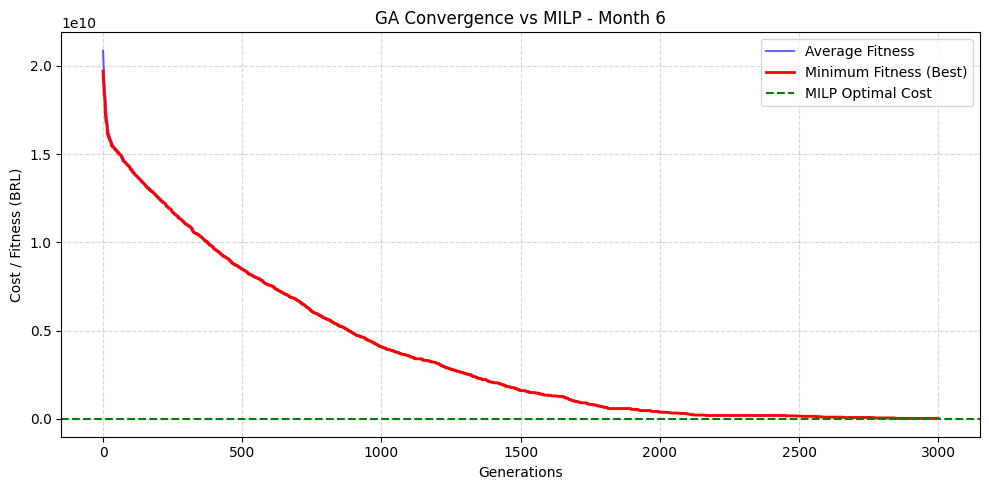


Visualization saved to /kaggle/working/ga_convergence_month_6.png


In [4]:
# ============================================================
# CELL 5: MULTI-PERIOD SOLVER LOOP & ACADEMIC COMPARISON (MILP vs GA)
# ============================================================
import pulp
import random, time
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

def solve_milp_for_month(month_idx, d, C, f_cost, F, D, k, S_CAP):
    prob = pulp.LpProblem(f'CWLP_Month_{month_idx}', pulp.LpMinimize)
    y = {i: pulp.LpVariable(f'y_{i}', cat='Binary') for i in F}
    x = {(i, j): pulp.LpVariable(f'x_{i}_{j}', lowBound=0, cat='Continuous') for i in F for j in D}
    S = {i: S_CAP for i in F}

    # Hàm mục tiêu (Objective)
    prob += (
        pulp.lpSum(C.get((i, j), 1e9) * x[(i, j)] for i in F for j in D)
        + pulp.lpSum(f_cost[i] * y[i] for i in F)
    )
    # Ràng buộc (Constraints)
    for j in D:
        prob += pulp.lpSum(x[(i, j)] for i in F) == d.get(j, 0) # Ràng buộc phục vụ cầu
    for i in F:
        prob += pulp.lpSum(x[(i, j)] for j in D) <= S[i] * y[i] # Ràng buộc sức chứa
    prob += pulp.lpSum(y[i] for i in F) <= k                    # Ràng buộc số kho tối đa

    t0 = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=60))
    elapsed = time.time() - t0

    if prob.status in (1, -2):
        milp_hubs = [i for i in F if pulp.value(y[i]) > 0.5]
        transport_cost = sum(C.get((i, j), 1e9) * pulp.value(x[(i, j)]) for i in F for j in D)
        fixed_cost_total = sum(f_cost[i] * pulp.value(y[i]) for i in F)
        return {
            'month': month_idx,
            'solver': 'MILP',
            'status': pulp.LpStatus[prob.status],
            'opened_hubs': str(sorted(milp_hubs)),
            'n_hubs': len(milp_hubs),
            'transport_cost': float(transport_cost),
            'fixed_cost': float(fixed_cost_total),
            'total_cost': float(transport_cost + fixed_cost_total),
            'S_CAP': float(S_CAP),
            'time_s': round(elapsed, 1)
        }
    return None

def solve_ga_for_month(month_idx, d, C, f_cost, F, D, k, S_CAP):
    F_list = sorted(F)
    D_list = sorted(D)
    nF, nD = len(F_list), len(D_list)

    C_arr = np.array([[C.get((fi, dj), 1e9) for dj in D_list] for fi in F_list])
    d_arr = np.array([d.get(dj, 0) for dj in D_list])
    S_arr = np.array([S_CAP for fi in F_list])
    f_arr = np.array([f_cost[fi] for fi in F_list])

    POP_SIZE, CXPB, MUTPB, TOURN_SIZE = 50, 0.9, 0.1, 2
    IND_SIZE = nF * nD
    PENALTY = float(max(C_arr.max() * nD * 10, 1e6))
    NGEN = 3000  # Thiết lập 3000 thế hệ theo đúng paper Milazzo et al. (2022)

    def evaluate(individual):
        mat = np.asarray(individual, dtype=np.float64).reshape(nF, nD)
        x = mat * d_arr
        y = (mat.sum(axis=1) > 0).astype(np.float64)
        transport = float(np.sum(C_arr * x))
        fixed = float(np.dot(f_arr, y))
        load = x.sum(axis=1)
        
        # 4 Penalties theo đúng paper Milazzo et al. (2022) - không có ràng buộc k trong GA
        v1 = float(np.sum(np.maximum(0.0, load - S_arr))) # Vượt sức chứa (Restrição 1)
        coverage = mat.sum(axis=0)
        v2 = float((coverage == 0).sum())                 # Bỏ lọt khách hàng (Restrição 2)
        v3 = float(np.sum(np.maximum(0.0, coverage - 1))) # 1 Khách nhận từ nhiều kho (Restrição 3)
        v4 = float(max(0.0, mat.sum() - nD))              # Lượng phục vụ dư thừa (Restrição 4)
        
        penalty = PENALTY * (v1 + v2 + v3 + v4)
        return (transport + fixed + penalty,)

    # Reset DEAP registry
    for cls in ("FitnessMin", "Individual"):
        if hasattr(creator, cls): delattr(creator, cls)
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMin)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=IND_SIZE)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / IND_SIZE)
    toolbox.register("select", tools.selTournament, tournsize=TOURN_SIZE)

    # Thống kê sự hội tụ (Statistics Tracking)
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    logbook = tools.Logbook()
    logbook.header = ["gen", "nevals"] + stats.fields

    pop = toolbox.population(n=POP_SIZE)
    hof = tools.HallOfFame(1)
    
    t0 = time.time()
    # Khởi tạo và đánh giá quần thể ban đầu
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit
    hof.update(pop)
    logbook.record(gen=0, nevals=len(pop), **stats.compile(pop))
    
    # Tiến hóa qua các thế hệ với cơ chế Elitism (giữ cá thể tốt nhất) theo Milazzo et al. (2022)
    for gen in range(1, NGEN + 1):
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))
        
        # Áp dụng Crossover
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values
                
        # Áp dụng Đột biến
        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values
                
        # Đánh giá các cá thể bị biến đổi
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
            
        # Elitism: Thay thế cá thể xấu nhất bằng cá thể tốt nhất trong Hall of Fame
        if len(hof) > 0:
            worst_idx = np.argmax([ind.fitness.values[0] for ind in offspring])
            offspring[worst_idx] = toolbox.clone(hof[0])
            
        pop[:] = offspring
        hof.update(pop)
        logbook.record(gen=gen, nevals=len(invalid_ind), **stats.compile(pop))
        
    elapsed = time.time() - t0

    best_mat = np.asarray(hof[0]).reshape(nF, nD)
    ga_hubs = [F_list[i] for i in range(nF) if best_mat[i].sum() > 0]
    x_ga = best_mat * d_arr
    transport_ga = float(np.sum(C_arr * x_ga))
    fixed_ga = float(np.dot(f_arr, (best_mat.sum(axis=1) > 0).astype(float)))
    
    # Kiểm tra Feasibility theo đúng 4 ràng buộc của paper
    coverage_final = best_mat.sum(axis=0)
    n_uncovered = int((coverage_final == 0).sum())
    n_multi = int((coverage_final > 1).sum())
    n_cap_viol = int(((x_ga.sum(axis=1)) > (S_arr + 1e-6)).sum())
    feasible_ga = (n_uncovered == 0 and n_multi == 0 and n_cap_viol == 0)

    res = {
        'month': month_idx,
        'solver': 'GA',
        'status': 'Feasible' if feasible_ga else 'Infeasible',
        'opened_hubs': str(sorted(ga_hubs)),
        'n_hubs': len(ga_hubs),
        'transport_cost': round(transport_ga, 4),
        'fixed_cost': round(fixed_ga, 2),
        'total_cost': round(transport_ga + fixed_ga, 4),
        'S_CAP': float(S_CAP),
        'time_s': round(elapsed, 1)
    }
    return res, logbook

print('\n' + '='*80)
print('MULTI-PERIOD OPTIMIZATION & COMPARISON (6 MONTHS)')
print('='*80)

all_results = []
ga_logbooks = {} # Lưu logbook để vẽ biểu đồ
INITIAL_S_CAP = 5.0

for month in range(1, 7):
    month_data = monthly_demand[monthly_demand['month_idx'] == month]
    d_dict = dict(zip(month_data['destination'], month_data['demand']))
    total_dem = sum(d_dict.values())
    
    if total_dem == 0:
        continue

    # Auto-adjust S_CAP
    min_req_cap = math.ceil((total_dem / k) * 1.1 * 1000) / 1000
    S_CAP = max(INITIAL_S_CAP, min_req_cap)
    
    print(f'\n--- THÁNG {month} --- Demand: {total_dem:.4f} m3 | S_CAP: {S_CAP:.3f} m3')
    
    # 1. MILP (Nghiệm tối ưu)
    res_milp = solve_milp_for_month(month, d_dict, C, f_cost, F, D, k, S_CAP)
    cost_milp = res_milp['total_cost'] if res_milp else float('inf')
    if res_milp:
        all_results.append(res_milp)
        print(f"  [MILP] Hubs: {res_milp['n_hubs']:2d} | Opened: {res_milp['opened_hubs']}")
        print(f"         Cost: {res_milp['total_cost']:,.2f} BRL (Trans: {res_milp['transport_cost']:,.2f}, Fixed: {res_milp['fixed_cost']:,.2f}) | Time: {res_milp['time_s']}s")
        
    # 2. GA (Nghiệm xấp xỉ)
    res_ga, logbook = solve_ga_for_month(month, d_dict, C, f_cost, F, D, k, S_CAP)
    all_results.append(res_ga)
    ga_logbooks[month] = logbook
    
    # Tính Optimality Gap
    cost_ga = res_ga['total_cost']
    gap = ((cost_ga - cost_milp) / cost_milp * 100) if cost_milp != float('inf') else float('nan')
    res_ga['optimality_gap_pct'] = gap
    
    feas_tag = "OK" if res_ga['status'] == "Feasible" else "FAIL"
    print(f"  [GA]   Hubs: {res_ga['n_hubs']:2d} | Opened: {res_ga['opened_hubs']}")
    print(f"         Cost: {cost_ga:,.2f} BRL (Trans: {res_ga['transport_cost']:,.2f}, Fixed: {res_ga['fixed_cost']:,.2f}) | Time: {res_ga['time_s']:>4.1f}s | Gap: {gap:>6.2f}% | Feas: {feas_tag}")

# Lưu kết quả
results_df = pd.DataFrame(all_results)
results_df.to_csv(WORK_ROOT / 'cwlp_comparative_results.csv', index=False)

# ==================================================
# BÁO CÁO SO SÁNH TỔNG HỢP (Comparative Report)
# ==================================================
print('\n' + '='*80)
print('BÁO CÁO SO SÁNH MILP VÀ GA (COMPARATIVE REPORT)')
print('='*80)

# Tạo bảng Pivot so sánh chi tiết
milp_df = results_df[results_df['solver'] == 'MILP'].set_index('month')
ga_df = results_df[results_df['solver'] == 'GA'].set_index('month')

comp_df = pd.DataFrame({
    'MILP_Hubs': milp_df['n_hubs'],
    'MILP_Opened': milp_df['opened_hubs'],
    'MILP_TransCost': milp_df['transport_cost'].round(2),
    'MILP_FixedCost': milp_df['fixed_cost'].round(2),
    'MILP_TotalCost': milp_df['total_cost'].round(2),
    'GA_Hubs': ga_df['n_hubs'],
    'GA_Opened': ga_df['opened_hubs'],
    'GA_TransCost': ga_df['transport_cost'].round(2),
    'GA_FixedCost': ga_df['fixed_cost'].round(2),
    'GA_TotalCost': ga_df['total_cost'].round(2),
    'Gap (%)': ga_df['optimality_gap_pct'].round(2),
    'MILP_Time(s)': milp_df['time_s'],
    'GA_Time(s)': ga_df['time_s'],
    'GA_Feasible': ga_df['status']
})
display(comp_df)

# ==================================================
# VẼ BIỂU ĐỒ HỘI TỤ (Convergence Graph)
# Bắt chước Hình 5, 7, 9 trong bài báo (Fitness vs Generation)
# ==================================================
last_month = max(ga_logbooks.keys())
log = ga_logbooks[last_month]

gen = log.select("gen")
fit_mins = log.select("min")
fit_avgs = log.select("avg")

plt.figure(figsize=(10, 5))
plt.plot(gen, fit_avgs, label='Average Fitness', color='blue', alpha=0.6)
plt.plot(gen, fit_mins, label='Minimum Fitness (Best)', color='red', linewidth=2)
# Vẽ thêm đường MILP Cost để so sánh
if last_month in milp_df.index:
    plt.axhline(y=milp_df.loc[last_month, 'total_cost'], color='green', linestyle='--', label='MILP Optimal Cost')

plt.title(f'GA Convergence vs MILP - Month {last_month}')
plt.xlabel('Generations')
plt.ylabel('Cost / Fitness (BRL)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(WORK_ROOT / f'ga_convergence_month_{last_month}.png', dpi=300)
plt.show()

print(f"\nVisualization saved to {WORK_ROOT}/ga_convergence_month_{last_month}.png")

In [ ]:
!pip install chronos-forecasting "transformers<4.40.0"

# ============================================================
# CELL 6: BASELINE COMPARISON — Amazon Chronos-T5-Small (46M)
# ============================================================
import time
import torch
import numpy as np
import pandas as pd
from chronos import ChronosPipeline

print('\n' + '='*80)
print('KHOẢNG CÁCH BASELINE: CHRONOS-T5-SMALL (46M Parameters)')
print('='*80)

# 1. Khởi tạo Pipeline
print(">>> Đang tải mô hình amazon/chronos-t5-small...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16,
)
print(">>> Tải mô hình thành công!")

# 2. Định nghĩa hàm Inference trên tập Test (kế thừa test_hist_groups và test_df từ Cell 3)
def run_chronos_split_inference(hist_groups: dict, target_df: pd.DataFrame, split_name: str):
    tgt_groups = {uid: g.sort_values('ds') for uid, g in target_df.groupby('unique_id')}
    pred_rows = []
    start = time.time()
    
    for i, uid in enumerate(sorted(tgt_groups.keys()), 1):
        if uid not in hist_groups:
            continue
        h, t = hist_groups[uid], tgt_groups[uid]
        if len(h) == 0 or len(t) == 0:
            continue
            
        pred_len = int(len(t))
        # Chronos nhận context là 1D tensor
        context = torch.tensor(h['y'].to_numpy(float))
        
        # Chronos predict returns shape: (batch_size, num_samples, prediction_length)
        forecast = pipeline.predict(
            context,
            prediction_length=pred_len,
            num_samples=20,
        )
        # Sử dụng nội suy trung vị (Median quantile) làm Point Forecast
        yhat = np.quantile(forecast[0].numpy(), 0.5, axis=0)
        yhat = np.clip(yhat, 0, None) # Không cho phép số âm
        
        for ds_s, yt, yp in zip(t['ds'].dt.strftime('%Y-%m-%d'), t['y'].to_numpy(float), yhat):
            pred_rows.append({'unique_id': uid, 'ds': ds_s, 'y_true': float(yt), 'yhat_mamba': float(yp)})
            
        if i % 250 == 0:
            print(f'  [{split_name} - Chronos] {i}/{len(tgt_groups)} series | {time.time()-start:.1f}s')
            
    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(WORK_ROOT / f'olist_chronos_{split_name}_predictions.csv', index=False)
    return pred_df

print('\n>>> Đang chạy Inference bằng Chronos trên tập TEST...')
test_pred_chronos = run_chronos_split_inference(test_hist_groups, test_df, 'test')

# 3. Đánh giá Metrics (Tái sử dụng metric_dict từ Cell 3)
print('\n' + '=' * 60)
print('EVALUATION METRICS — Chronos-T5-Small (TEST set)')
print('=' * 60)

kpi_chronos = metric_dict(test_pred_chronos, test_hist_groups, seasonality=1)

print(f'  MAE              : {kpi_chronos["mae"]:.2f}%')
print(f'  RMSE             : {kpi_chronos["rmse"]:.2f}%')
print(f'  sMAPE (all)      : {kpi_chronos["smape"]:.2f}%')
print(f'  sMAPE (nonzero)  : {kpi_chronos["smape_nonzero"]:.2f}%')
print(f'  MASE             : {kpi_chronos["mase"]:.4f}')
print(f'  Total points     : {kpi_chronos["n"]:,}')

kpi_chronos_df = pd.DataFrame([{'split': 'test', 'model': 'chronos_t5_small', **kpi_chronos}])
kpi_chronos_df.to_csv(WORK_ROOT / 'olist_chronos_test_kpi.csv', index=False)
display(kpi_chronos_df)

# 4. Dự báo tương lai 24 tuần (Future Inference)
def run_chronos_future_inference(hist_groups: dict, periods: int = 24, freq: str = 'W'):
    pred_rows = []
    start = time.time()
    
    for i, (uid, h) in enumerate(sorted(hist_groups.items()), 1):
        if len(h) == 0:
            continue
        last_date = h['ds'].max()
        future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=periods, freq=freq)
        
        context = torch.tensor(h['y'].to_numpy(float))
        forecast = pipeline.predict(
            context,
            prediction_length=periods,
            num_samples=20,
        )
        yhat = np.quantile(forecast[0].numpy(), 0.5, axis=0)
        yhat = np.clip(yhat, 0, None)
        
        for week_idx, (ds_s, yp) in enumerate(zip(future_dates.strftime('%Y-%m-%d'), yhat)):
            pred_rows.append({'unique_id': uid, 'ds': ds_s, 'week_idx': week_idx + 1, 'yhat_mamba': float(yp)})
            
        if i % 250 == 0:
            print(f'  [Future - Chronos] {i}/{len(hist_groups)} series | {time.time()-start:.1f}s')
            
    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(WORK_ROOT / 'olist_chronos_future_predictions.csv', index=False)
    return pred_df

print('\n>>> Chạy Future Inference bằng Chronos cho 24 tuần tiếp theo...')
future_chronos_df = run_chronos_future_inference(future_hist_groups, periods=24, freq='W')
future_chronos_df['month_idx'] = ((future_chronos_df['week_idx'] - 1) // 4) + 1
print(f"Future Predictions (Chronos): {len(future_chronos_df):,} rows")
display(future_chronos_df.head())

In [ ]:
# ============================================================
# CELL 7: BASELINE COMPARISON — Seasonal Naive (S-Naive)
# ============================================================
import time
import numpy as np
import pandas as pd

print('\n' + '='*80)
print('KHOẢNG CÁCH BASELINE: SEASONAL NAIVE (S-Naive, S=4)')
print('='*80)

# 1. Định nghĩa hàm Inference trên tập Test (kế thừa test_hist_groups và test_df từ Cell 3)
def run_snaive_split_inference(hist_groups: dict, target_df: pd.DataFrame, split_name: str, S: int = 4):
    tgt_groups = {uid: g.sort_values('ds') for uid, g in target_df.groupby('unique_id')}
    pred_rows = []
    start = time.time()
    
    for i, uid in enumerate(sorted(tgt_groups.keys()), 1):
        if uid not in hist_groups:
            continue
        h, t = hist_groups[uid], tgt_groups[uid]
        if len(h) == 0 or len(t) == 0:
            continue
            
        pred_len = int(len(t))
        h_y = h['y'].to_numpy(float)
        
        # S-Naive: Lấy S tuần lịch sử cuối cùng và lặp lại cho đến khi đủ khoảng pred_len
        if len(h_y) >= S:
            cycle = h_y[-S:]
        else:
            cycle = np.repeat(h_y[-1], S)
            
        # Lặp lại chu kỳ (tiled) và cắt đúng độ dài cần dự báo
        yhat = np.tile(cycle, int(np.ceil(pred_len / S)))[:pred_len]
        yhat = np.clip(yhat, 0, None)  # Không cho phép số âm
        
        for ds_s, yt, yp in zip(t['ds'].dt.strftime('%Y-%m-%d'), t['y'].to_numpy(float), yhat):
            pred_rows.append({'unique_id': uid, 'ds': ds_s, 'y_true': float(yt), 'yhat_mamba': float(yp)})
            
        if i % 250 == 0:
            print(f'  [{split_name} - S-Naive] {i}/{len(tgt_groups)} series | {time.time()-start:.1f}s')
            
    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(WORK_ROOT / f'olist_snaive_{split_name}_predictions.csv', index=False)
    return pred_df

print('\n>>> Đang chạy Inference bằng S-Naive trên tập TEST...')
test_pred_snaive = run_snaive_split_inference(test_hist_groups, test_df, 'test', S=4)

# 2. Đánh giá Metrics (Tái sử dụng metric_dict từ Cell 3)
print('\n' + '=' * 60)
print('EVALUATION METRICS — Seasonal Naive (TEST set)')
print('=' * 60)

kpi_snaive = metric_dict(test_pred_snaive, test_hist_groups, seasonality=1)

print(f'  MAE              : {kpi_snaive["mae"]:.2f}%')
print(f'  RMSE             : {kpi_snaive["rmse"]:.2f}%')
print(f'  sMAPE (all)      : {kpi_snaive["smape"]:.2f}%')
print(f'  sMAPE (nonzero)  : {kpi_snaive["smape_nonzero"]:.2f}%')
print(f'  MASE             : {kpi_snaive["mase"]:.4f}')
print(f'  Total points     : {kpi_snaive["n"]:,}')

kpi_snaive_df = pd.DataFrame([{'split': 'test', 'model': 'seasonal_naive', **kpi_snaive}])
kpi_snaive_df.to_csv(WORK_ROOT / 'olist_snaive_test_kpi.csv', index=False)
display(kpi_snaive_df)

# 3. Dự báo tương lai 24 tuần (Future Inference)
def run_snaive_future_inference(hist_groups: dict, periods: int = 24, freq: str = 'W', S: int = 4):
    pred_rows = []
    start = time.time()
    
    for i, (uid, h) in enumerate(sorted(hist_groups.items()), 1):
        if len(h) == 0:
            continue
        last_date = h['ds'].max()
        future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=periods, freq=freq)
        
        h_y = h['y'].to_numpy(float)
        if len(h_y) >= S:
            cycle = h_y[-S:]
        else:
            cycle = np.repeat(h_y[-1], S)
            
        yhat = np.tile(cycle, int(np.ceil(periods / S)))[:periods]
        yhat = np.clip(yhat, 0, None)
        
        for week_idx, (ds_s, yp) in enumerate(zip(future_dates.strftime('%Y-%m-%d'), yhat)):
            pred_rows.append({'unique_id': uid, 'ds': ds_s, 'week_idx': week_idx + 1, 'yhat_mamba': float(yp)})
            
        if i % 250 == 0:
            print(f'  [Future - S-Naive] {i}/{len(hist_groups)} series | {time.time()-start:.1f}s')
            
    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(WORK_ROOT / 'olist_snaive_future_predictions.csv', index=False)
    return pred_df

print('\n>>> Chạy Future Inference bằng S-Naive cho 24 tuần tiếp theo...')
future_snaive_df = run_snaive_future_inference(future_hist_groups, periods=24, freq='W', S=4)
future_snaive_df['month_idx'] = ((future_snaive_df['week_idx'] - 1) // 4) + 1
print(f"Future Predictions (S-Naive): {len(future_snaive_df):,} rows")
display(future_snaive_df.head())

In [5]:
# ============================================================
# CELL 8: COMPARISON BETWEEN MILP AND BENDERS DECOMPOSITION ALGORITHM (EXACT)
# ============================================================
import pulp
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def solve_milp_for_month(month_idx, d, C, f_cost, F, D, k, S_CAP):
    """
    Giải bài toán CWLP động tối ưu tuyệt đối bằng bộ giải chính xác MILP (CBC).
    """
    prob = pulp.LpProblem(f'CWLP_Month_{month_idx}', pulp.LpMinimize)
    y = {i: pulp.LpVariable(f'y_{i}', cat='Binary') for i in F}
    x = {(i, j): pulp.LpVariable(f'x_{i}_{j}', lowBound=0, cat='Continuous') for i in F for j in D}
    S = {i: S_CAP for i in F}

    # Hàm mục tiêu
    prob += (
        pulp.lpSum(C.get((i, j), 1e9) * x[(i, j)] for i in F for j in D)
        + pulp.lpSum(f_cost[i] * y[i] for i in F)
    )
    # Ràng buộc
    for j in D:
        prob += pulp.lpSum(x[(i, j)] for i in F) == d.get(j, 0)
    for i in F:
        prob += pulp.lpSum(x[(i, j)] for j in D) <= S[i] * y[i]
    prob += pulp.lpSum(y[i] for i in F) <= k

    t0 = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=60))
    elapsed = time.time() - t0

    if prob.status in (1, -2):
        milp_hubs = [i for i in F if pulp.value(y[i]) > 0.5]
        transport_cost = sum(C.get((i, j), 1e9) * pulp.value(x[(i, j)]) for i in F for j in D)
        fixed_cost = sum(f_cost[i] * pulp.value(y[i]) for i in F)
        return {
            'month': month_idx,
            'solver': 'MILP',
            'status': pulp.LpStatus[prob.status],
            'opened_hubs': str(sorted(milp_hubs)),
            'n_hubs': len(milp_hubs),
            'transport_cost': float(transport_cost),
            'fixed_cost': float(fixed_cost),
            'total_cost': float(transport_cost + fixed_cost),
            'S_CAP': float(S_CAP),
            'time_s': round(elapsed, 1)
        }
    return None

def solve_benders_for_month(month_idx, d, C, f_cost, F, D, k, S_CAP):
    """
    Giải bài toán CWLP động tối ưu tuyệt đối bằng thuật toán Phân rã Benders (Benders Decomposition).
    Mô hình hóa chính xác theo hệ phương trình (12)-(19) từ bài báo Benders (trang 6).
    Đầu vào: Giới hạn k kho. Đầu ra: Nghiệm tối ưu tuyệt đối (Gap = 0%).
    """
    t0 = time.time()
    total_demand = sum(d.values())
    if total_demand == 0:
        return None
        
    LB = -1e9
    UB = 1e9
    epsilon = 1.0  # Sai số hội tụ (BRL)
    max_iters = 1000  # Tăng số vòng lặp tối đa để đảm bảo hội tụ hoàn toàn
    
    # Chỉ giải cho các khách hàng thực sự có nhu cầu để tránh lỗi số học
    D_active = [j for j in D if d.get(j, 0.0) > 0.0]
    if not D_active:
        return None
        
    # 1. Khởi tạo Master Problem (phương trình 19 trong paper)
    master_prob = pulp.LpProblem(f'Benders_Master_{month_idx}', pulp.LpMinimize)
    y = {i: pulp.LpVariable(f'y_m_{i}', cat='Binary') for i in F}
    z_trans = pulp.LpVariable('z_trans', lowBound=0, cat='Continuous')
    
    master_prob += pulp.lpSum(f_cost[i] * y[i] for i in F) + z_trans
    
    # RÀNG BUỘC KÊNH KHO K = 5
    master_prob += pulp.lpSum(y[i] for i in F) <= k
    
    # Ràng buộc khả thi tổng sức chứa cơ bản
    master_prob += pulp.lpSum(y[i] * S_CAP for i in F) >= total_demand
    
    iteration = 0
    best_y = None
    
    while (UB - LB > epsilon) and (iteration < max_iters):
        iteration += 1
        
        # Giải Master Problem để lấy cấu hình mở kho y_bar tạm thời
        master_status = master_prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=20))
        if master_status != 1:
            break
            
        LB = pulp.value(master_prob.objective)
        y_bar = {i: 1.0 if pulp.value(y[i]) > 0.5 else 0.0 for i in F}
        
        # Kiểm tra tính khả thi của công suất (Ràng buộc Feasibility)
        opened_cap = sum(S_CAP * y_bar[i] for i in F)
        if opened_cap < total_demand - 1e-5:
            # Sinh Feasibility Cut
            master_prob += pulp.lpSum(y[i] * S_CAP for i in F) >= total_demand
            continue
            
        # 2. Giải bài toán phụ đối ngẫu (Dual Subproblem) trên tập kho ĐÃ MỞ (F_open)
        # Kỹ thuật này triệt tiêu hoàn toàn sự vô hạn (unboundedness) của các kho đóng y_i = 0
        F_open_iter = [i for i in F if y_bar[i] > 0.5]
        sub_prob = pulp.LpProblem(f'Benders_Dual_Sub_{month_idx}_{iteration}', pulp.LpMaximize)
        
        # u_j là tự do, w_i >= 0
        u = {j: pulp.LpVariable(f'u_d_{j}', cat='Continuous') for j in D_active}
        w = {i: pulp.LpVariable(f'w_d_{i}', lowBound=0, cat='Continuous') for i in F_open_iter}
        
        # Hàm mục tiêu đối ngẫu chỉ chứa các kho đã mở
        sub_prob += (
            pulp.lpSum(d[j] * u[j] for j in D_active)
            - pulp.lpSum(S_CAP * w[i] for i in F_open_iter)
        )
        
        # Ràng buộc đối ngẫu: u_j - w_i <= C_ij
        for i in F_open_iter:
            for j in D_active:
                sub_prob += u[j] - w[i] <= C.get((i, j), 1e9)
                
        sub_status = sub_prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=20))
        
        if sub_status == 1:
            sub_obj = pulp.value(sub_prob.objective)
            u_val = {j: pulp.value(u[j]) for j in D_active}
            w_val_open = {i: pulp.value(w[i]) for i in F_open_iter}
            
            # Kiến tạo các giá trị đối ngẫu cho kho ĐÓNG để sinh Benders Cut đầy đủ
            # w_i = max(0, max_j(u_j - C_ij)) theo đúng lý thuyết đối ngẫu bài toán kho
            w_val = {}
            for i in F:
                if i in F_open_iter:
                    w_val[i] = w_val_open[i]
                else:
                    w_val[i] = max(0.0, max(u_val[j] - C.get((i, j), 1e9) for j in D_active))
            
            # Thêm lát cắt tối ưu Benders chuẩn xác (không dùng biến phụ v_ij thừa)
            master_prob += z_trans >= (
                pulp.lpSum(d[j] * u_val[j] for j in D_active)
                - pulp.lpSum(S_CAP * y[i] * w_val[i] for i in F)
            )
            
            # Cập nhật Cận trên (UB)
            fixed_cost = sum(f_cost[i] * y_bar[i] for i in F)
            current_cost = fixed_cost + sub_obj
            if current_cost < UB:
                UB = current_cost
                best_y = y_bar.copy()
            
            # In tiến độ hội tụ sau mỗi 10 vòng lặp
            if iteration % 10 == 0 or iteration == 1:
                print(f"  Vòng lặp {iteration:3d} | LB: {LB:10,.2f} BRL | UB: {UB:10,.2f} BRL")
        else:
            # Nếu bài toán con vô nghiệm hoặc lỗi số học, sinh Feasibility Cut
            master_prob += pulp.lpSum(y[i] * S_CAP for i in F) >= total_demand
            
    if best_y is None:
        best_y = {i: 1.0 if i in sorted(list(F))[:k] else 0.0 for i in F}
        
    # 3. Giải bài toán Vận tải cuối cùng
    F_open = [i for i in F if best_y[i] > 0.5]
    trans_prob = pulp.LpProblem('Benders_Final_Trans', pulp.LpMinimize)
    x_t = {(i, j): pulp.LpVariable(f'x_ft_{i}_{j}', lowBound=0, cat='Continuous') for i in F_open for j in D_active}
    trans_prob += pulp.lpSum(C.get((i, j), 1e9) * x_t[(i, j)] for i in F_open for j in D_active)
    
    for j in D_active:
        trans_prob += pulp.lpSum(x_t[(i, j)] for i in F_open) == d.get(j, 0.0)
    for i in F_open:
        trans_prob += pulp.lpSum(x_t[(i, j)] for j in D_active) <= S_CAP
        
    trans_prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=20))
    elapsed = time.time() - t0
    
    if trans_prob.status in (1, -2):
        transport_cost = sum(C.get((i, j), 1e9) * pulp.value(x_t[(i, j)]) for i in F_open for j in D_active)
        fixed_cost = sum(f_cost[i] for i in F_open)
        return {
            'month': month_idx,
            'solver': 'Benders',
            'status': 'Optimal' if trans_prob.status == 1 else 'Infeasible',
            'opened_hubs': str(sorted(F_open)),
            'n_hubs': len(F_open),
            'transport_cost': float(transport_cost),
            'fixed_cost': float(fixed_cost),
            'total_cost': float(transport_cost + fixed_cost),
            'S_CAP': float(S_CAP),
            'time_s': round(elapsed, 2)
        }
    return None

print('\n' + '='*80)
print('MULTI-PERIOD OPTIMIZATION & COMPARISON (MILP vs BENDERS DECOMPOSITION)')
print('='*80)

benders_results = []
INITIAL_S_CAP = 5.0

# Chạy so sánh 6 tháng trên cùng 1 bộ tham chiếu giống MILP
for month in range(1, 7):
    month_data = monthly_demand[monthly_demand['month_idx'] == month]
    d_dict = dict(zip(month_data['destination'], month_data['demand']))
    total_dem = sum(d_dict.values())
    
    if total_dem == 0:
        continue

    min_req_cap = math.ceil((total_dem / k) * 1.1 * 1000) / 1000
    S_CAP = max(INITIAL_S_CAP, min_req_cap)
    
    print(f'\n--- THÁNG {month} --- Demand: {total_dem:.4f} m3 | S_CAP: {S_CAP:.3f} m3')
    
    # 1. MILP
    res_milp = solve_milp_for_month(month, d_dict, C, f_cost, F, D, k, S_CAP)
    cost_milp = res_milp['total_cost'] if res_milp else float('inf')
    if res_milp:
        benders_results.append(res_milp)
        print(f"  [MILP]          Hubs: {res_milp['n_hubs']:2d} | Opened: {res_milp['opened_hubs']}")
        print(f"                  Cost: {res_milp['total_cost']:,.2f} BRL (Trans: {res_milp['transport_cost']:,.2f}, Fixed: {res_milp['fixed_cost']:,.2f}) | Time: {res_milp['time_s']}s")
        
    # 2. Benders
    res_benders = solve_benders_for_month(month, d_dict, C, f_cost, F, D, k, S_CAP)
    if res_benders:
        benders_results.append(res_benders)
        cost_benders = res_benders['total_cost']
        gap = ((cost_benders - cost_milp) / cost_milp * 100) if cost_milp != float('inf') else float('nan')
        res_benders['optimality_gap_pct'] = gap
        
        print(f"  [Benders]       Hubs: {res_benders['n_hubs']:2d} | Opened: {res_benders['opened_hubs']}")
        print(f"                  Cost: {cost_benders:,.2f} BRL (Trans: {res_benders['transport_cost']:,.2f}, Fixed: {res_benders['fixed_cost']:,.2f}) | Time: {res_benders['time_s']}s | Gap: {gap:>6.2f}%")

# ==================================================
# XUẤT BÁO CÁO BẢNG SO SÁNH MILP vs BENDERS
# ==================================================
print('\n' + '='*80)
print('BÁO CÁO SO SÁNH TỐI ƯU TUYỆT ĐỐI (MILP VS BENDERS)')
print('='*80)

results_df3 = pd.DataFrame(benders_results)
results_df3.to_csv(WORK_ROOT / 'cwlp_benders_comparative_results.csv', index=False)

milp_df3 = results_df3[results_df3['solver'] == 'MILP'].set_index('month')
benders_df3 = results_df3[results_df3['solver'] == 'Benders'].set_index('month')

comp_df3 = pd.DataFrame({
    'MILP_Hubs': milp_df3['n_hubs'],
    'MILP_TotalCost': milp_df3['total_cost'].round(2),
    'Benders_Hubs': benders_df3['n_hubs'],
    'Benders_TotalCost': benders_df3['total_cost'].round(2),
    'Gap (%)': benders_df3['optimality_gap_pct'].round(4),
    'MILP_Time(s)': milp_df3['time_s'],
    'Benders_Time(s)': benders_df3['time_s']
})
display(comp_df3)


MULTI-PERIOD OPTIMIZATION & COMPARISON (MILP vs BENDERS DECOMPOSITION)

--- THÁNG 1 --- Demand: 62.4023 m3 | S_CAP: 17.161 m3
  [MILP]          Hubs:  4 | Opened: ['04', '08', '13', '35']
                  Cost: 78,681.50 BRL (Trans: 76,681.50, Fixed: 2,000.00) | Time: 0.9s
  Vòng lặp   1 | LB:   2,000.00 BRL | UB: 203,629.34 BRL
  Vòng lặp  10 | LB:  41,373.34 BRL | UB:  83,077.20 BRL
  Vòng lặp  20 | LB:  51,998.43 BRL | UB:  82,541.65 BRL
  Vòng lặp  30 | LB:  58,849.12 BRL | UB:  82,541.65 BRL
  Vòng lặp  40 | LB:  61,839.88 BRL | UB:  82,541.65 BRL
  Vòng lặp  50 | LB:  66,317.28 BRL | UB:  79,200.26 BRL
  Vòng lặp  60 | LB:  67,863.20 BRL | UB:  79,200.26 BRL
  Vòng lặp  70 | LB:  69,617.02 BRL | UB:  79,200.26 BRL
  Vòng lặp  80 | LB:  70,881.85 BRL | UB:  79,200.26 BRL
  Vòng lặp  90 | LB:  72,197.56 BRL | UB:  79,200.26 BRL
  Vòng lặp 100 | LB:  72,839.12 BRL | UB:  79,200.26 BRL
  Vòng lặp 110 | LB:  74,400.41 BRL | UB:  79,200.26 BRL
  Vòng lặp 120 | LB:  74,905.07 BRL | UB

,MILP_Hubs,MILP_TotalCost,Benders_Hubs,Benders_TotalCost,Gap (%),MILP_Time(s),Benders_Time(s)
month,,,,,,,
1,4,78681.50,4,78681.50,0.0,0.9,195.52
2,4,76955.58,4,76955.58,0.0,0.9,158.16
3,4,73843.92,4,73843.92,0.0,1.1,155.97
4,4,72206.47,4,72206.47,0.0,0.9,153.06
5,4,71564.39,4,71564.39,0.0,0.8,156.82
6,4,70295.31,4,70295.31,0.0,0.9,139.00
